In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import library to save model
import joblib

In [2]:
# Load student performance dataset

df = pd.read_csv("student_data.csv")

# Display first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# Display number of rows and columns

print("Dataset Shape:")
print(df.shape)

# Display column information
print("\nDataset Information:")
df.info()

Dataset Shape:
(395, 33)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 

In [4]:
# Check missing values in dataset

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [5]:
# Create target categories based on final grade (G3)

def performance(g3):

    if g3 >= 15:
        return "High"

    elif g3 >= 10:
        return "Average"

    else:
        return "Low"

# Create new target column

df["Performance"] = df["G3"].apply(performance)

# Display sample output

df[["G3", "Performance"]].head()

,G3,Performance
0,6,Low
1,6,Low
2,10,Average
3,15,High
4,10,Average


In [6]:
# Convert text columns into numeric values

le = LabelEncoder()

for col in df.columns:

    # Encode only object/string columns
    if df[col].dtype == "object" and col != "Performance":

        df[col] = le.fit_transform(df[col])

# Check first 5 rows after encoding

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Performance
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Low
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Low
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Average
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,High
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Average


In [7]:
# Features (Input Variables)

X = df.drop(["Performance", "G3"], axis=1)

# Target Variable

y = df["Performance"]

# Check dimensions

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (395, 32)
Target Shape: (395,)


In [11]:
# Encode target variable

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(df["Performance"])

print(y[:10])

[2 2 0 1 0 1 0 2 1 1]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(316, 32)
(316,)


In [15]:
print("Type of y:", type(y))
print("Type of y_train:", type(y_train))

print("\nShape of y:", y.shape)
print("Shape of y_train:", y_train.shape)

print("\nFirst 5 values:")
print(y_train[:5])

Type of y: <class 'numpy.ndarray'>
Type of y_train: <class 'numpy.ndarray'>

Shape of y: (395,)
Shape of y_train: (316,)

First 5 values:
[0 0 2 2 2]


In [16]:
print(X_train.dtypes.value_counts())

str      17
int64    15
Name: count, dtype: int64


In [17]:
print(X_train.head())

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
181     GP   M   16       U     GT3       T     3     3  services     other   
194     GP   M   16       U     GT3       T     2     3     other     other   
173     GP   F   16       U     GT3       T     1     3   at_home  services   
63      GP   F   16       U     GT3       T     4     3   teacher    health   
253     GP   M   16       R     GT3       T     2     1     other     other   

     ... romantic famrel  freetime  goout  Dalc Walc health absences  G1  G2  
181  ...      yes      4         2      3     1    2      3        2  12  13  
194  ...       no      5         3      3     1    1      3        0  13  14  
173  ...      yes      4         3      5     1    1      3        0   8   7  
63   ...       no      3         4      4     2    4      4        2  10   9  
253  ...       no      3         3      2     1    3      3        0   8   9  

[5 rows x 32 columns]


In [18]:
# Check which columns are still text

print(X_train.select_dtypes(include=['object']).columns)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_25452\1134069148.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns)


In [19]:
# Convert all string columns into numbers

from sklearn.preprocessing import LabelEncoder

for col in df.columns:

    if str(df[col].dtype) == "str":

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

print("All text columns encoded successfully")

All text columns encoded successfully


In [20]:
print(df.dtypes.value_counts())

int64    34
Name: count, dtype: int64


In [21]:
# Features
X = df.drop(["Performance", "G3"], axis=1)

# Target
y = df["Performance"]

print(X.dtypes.value_counts())

int64    32
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [24]:
model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [25]:
# Predict student performance

pred = model.predict(X_test)

print(pred[:10])

[2 0 2 0 2 0 1 2 2 0]


In [27]:
# Calculate accuracy

accuracy = accuracy_score(y_test, pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8607594936708861


In [28]:
# Display classification report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       1.00      0.80      0.89        20
           2       0.86      0.89      0.87        27

    accuracy                           0.86        79
   macro avg       0.89      0.85      0.87        79
weighted avg       0.87      0.86      0.86        79



In [29]:
# Generate confusion matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[28  0  4]
 [ 4 16  0]
 [ 3  0 24]]


In [30]:
# Save trained model

import joblib

joblib.dump(model, "model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


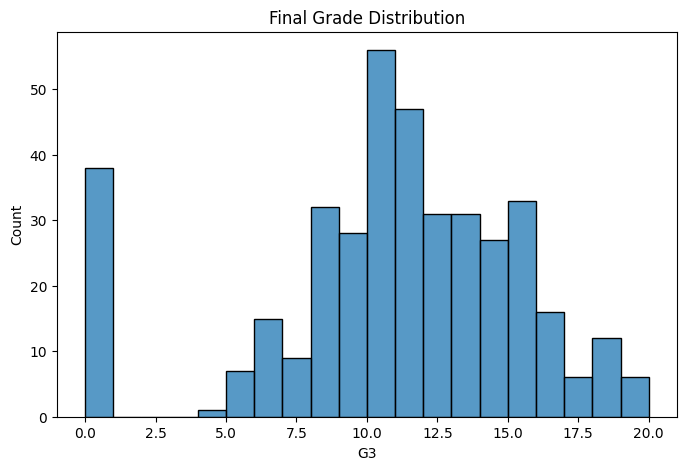

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20)

plt.title("Final Grade Distribution")

plt.show()

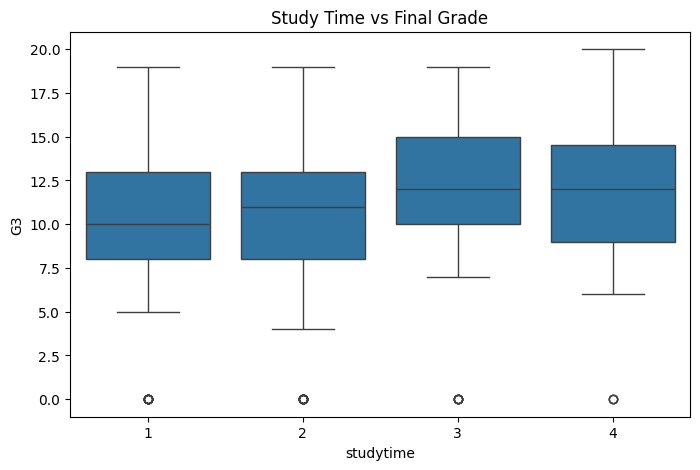

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")

plt.show()

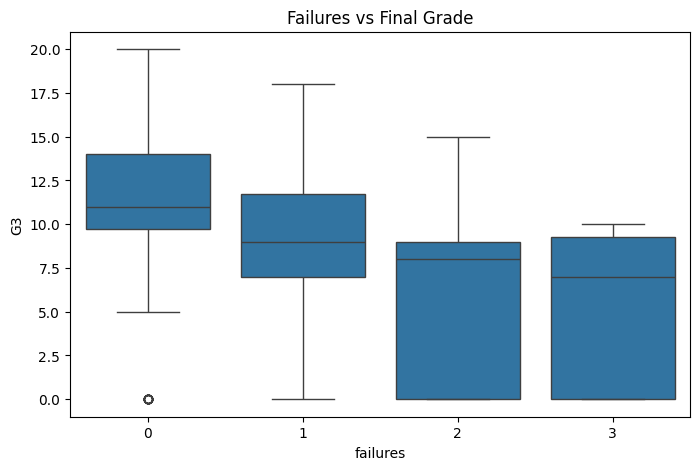

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x="failures", y="G3", data=df)

plt.title("Failures vs Final Grade")

plt.show()

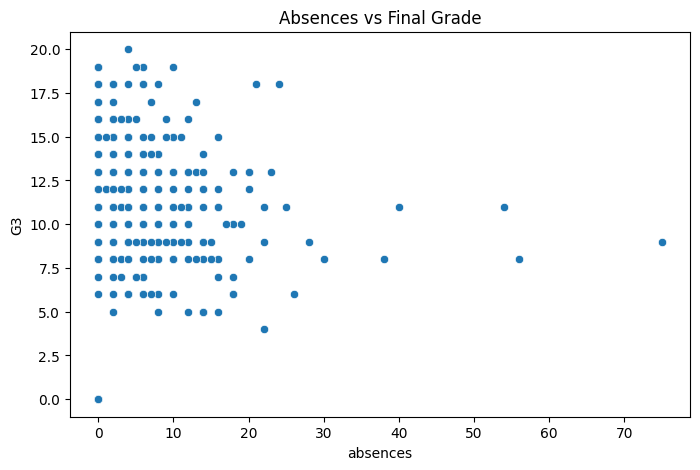

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")

plt.show()

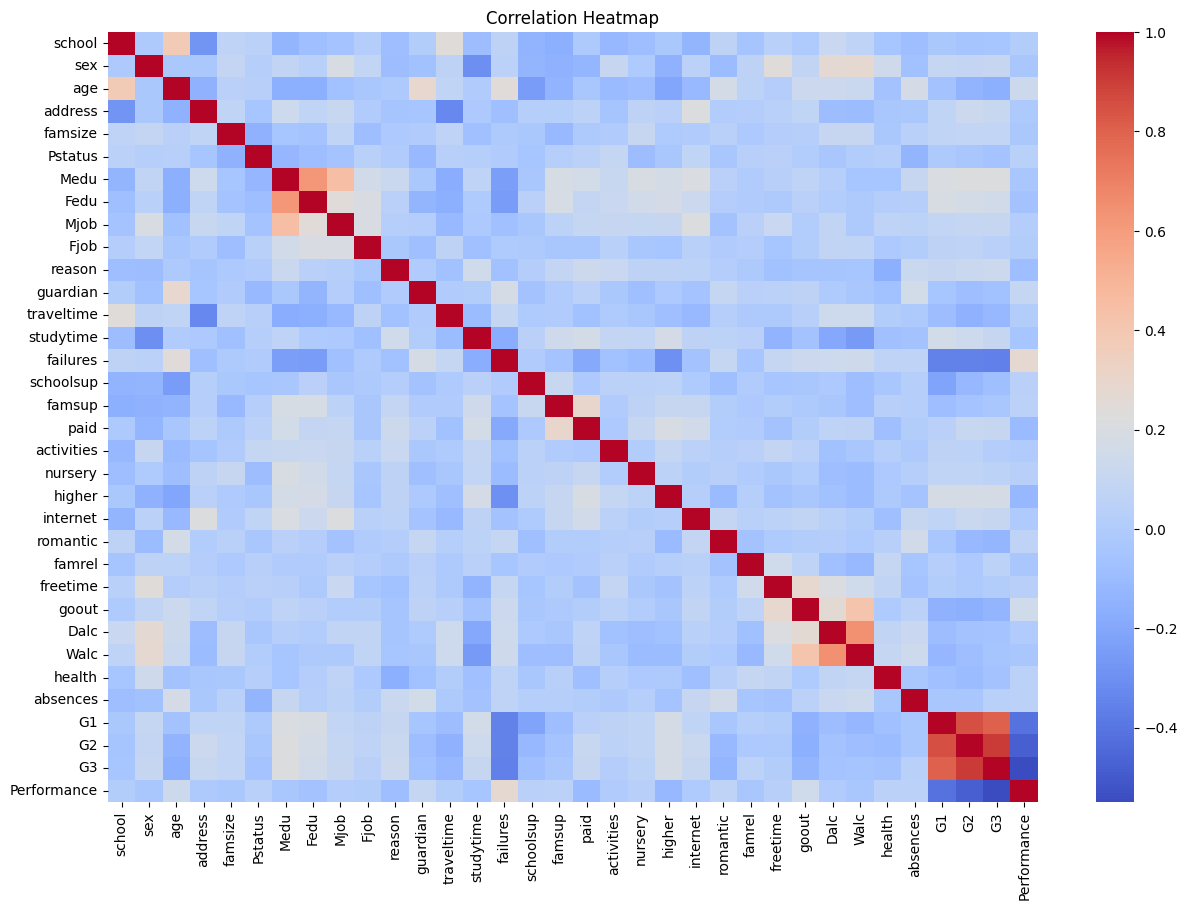

In [35]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

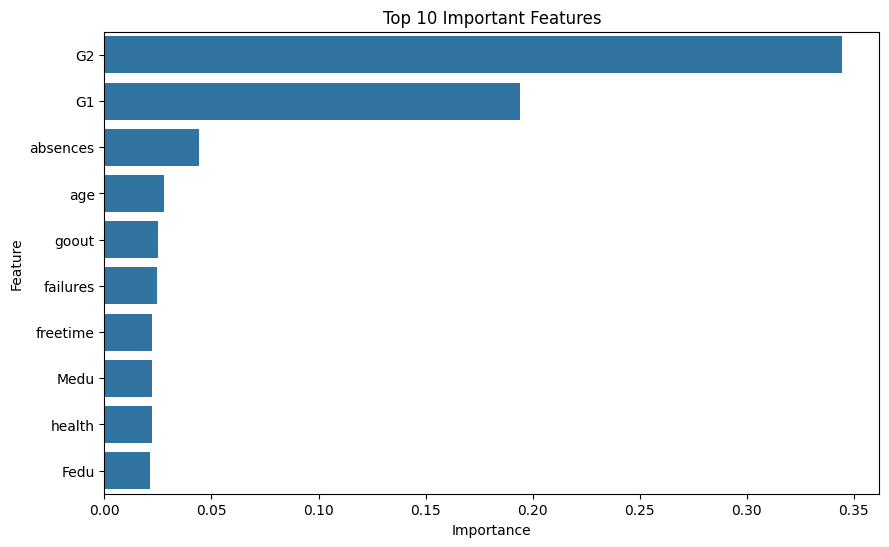

In [36]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [37]:
def recommendation(studytime, failures, absences):

    recommendations = []

    if studytime < 2:
        recommendations.append(
            "Increase study time."
        )

    if failures > 0:
        recommendations.append(
            "Focus on weak subjects."
        )

    if absences > 10:
        recommendations.append(
            "Improve attendance."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Excellent performance. Keep it up!"
        )

    return recommendations


print(recommendation(1, 2, 15))

['Increase study time.', 'Focus on weak subjects.', 'Improve attendance.']


In [38]:
# Predict student performance

pred = model.predict(X_test)

# Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.8607594936708861


In [39]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       1.00      0.80      0.89        20
           2       0.86      0.89      0.87        27

    accuracy                           0.86        79
   macro avg       0.89      0.85      0.87        79
weighted avg       0.87      0.86      0.86        79



In [40]:
import joblib

joblib.dump(model, "model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [41]:
print("Project Completed Successfully")

print("""
Conclusion:

1. Student Performance Prediction System developed successfully.
2. Random Forest Classifier used for prediction.
3. Data preprocessing and feature encoding performed.
4. Exploratory Data Analysis completed.
5. Recommendation System developed.
6. Model can predict High, Average and Low performance students.
""")

Project Completed Successfully

Conclusion:

1. Student Performance Prediction System developed successfully.
2. Random Forest Classifier used for prediction.
3. Data preprocessing and feature encoding performed.
4. Exploratory Data Analysis completed.
5. Recommendation System developed.
6. Model can predict High, Average and Low performance students.



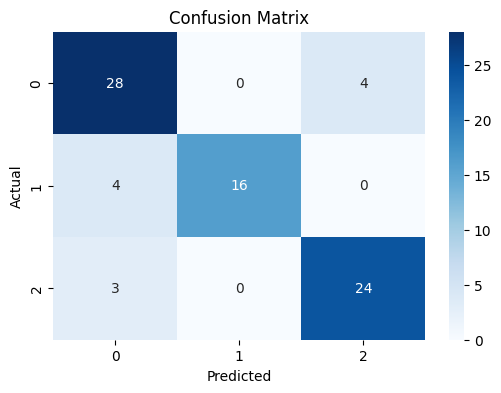

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

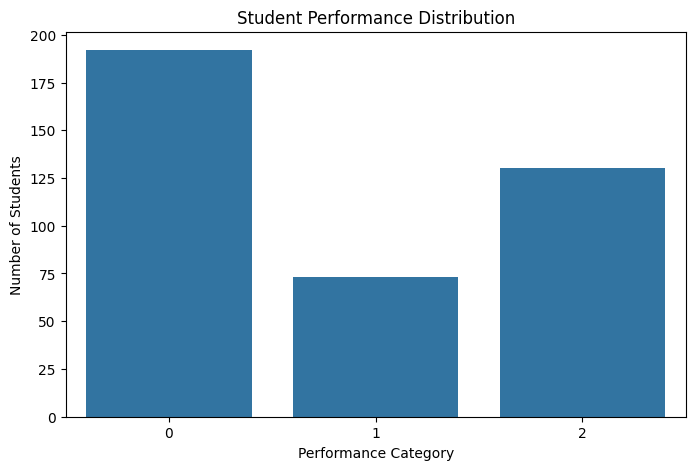

In [43]:
# Dashboard Chart 1
# Display the number of students in each performance category

plt.figure(figsize=(8,5))

sns.countplot(x=df["Performance"])

plt.title("Student Performance Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

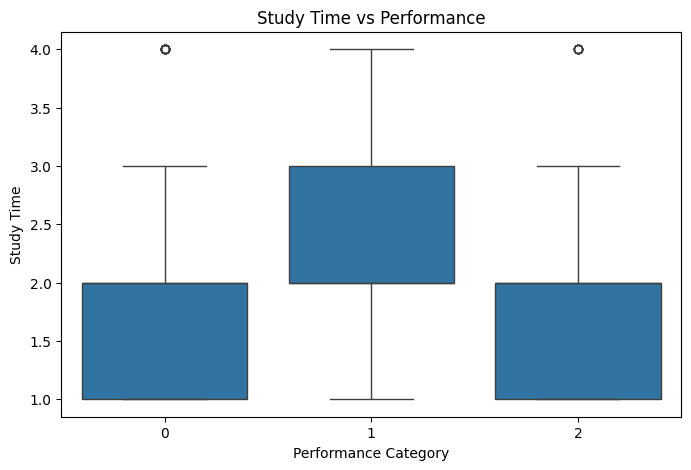

In [44]:
# Dashboard Chart 2
# Analyze how study time affects student performance

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Performance"],
    y=df["studytime"]
)

plt.title("Study Time vs Performance")
plt.xlabel("Performance Category")
plt.ylabel("Study Time")

plt.show()

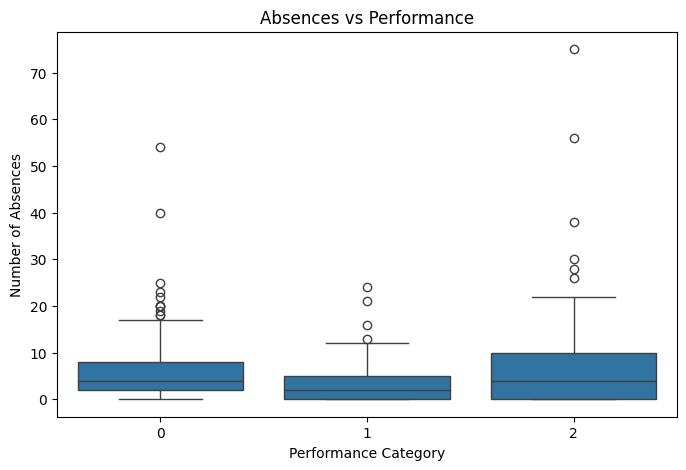

In [45]:
# Dashboard Chart 3
# Analyze relationship between absences and performance

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Performance"],
    y=df["absences"]
)

plt.title("Absences vs Performance")
plt.xlabel("Performance Category")
plt.ylabel("Number of Absences")

plt.show()

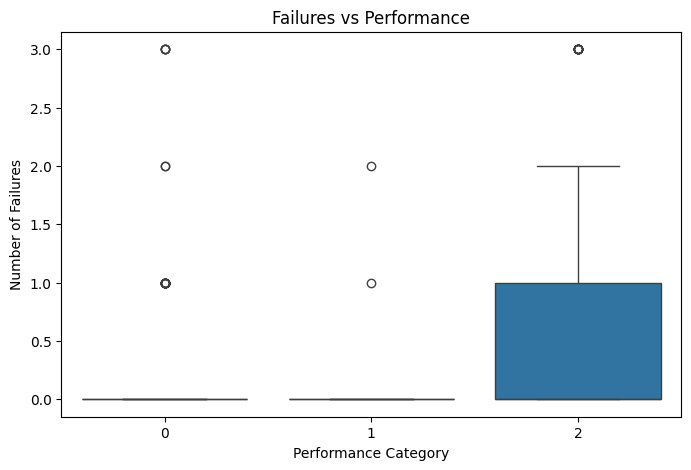

In [46]:
# Dashboard Chart 4
# Analyze how previous failures impact performance

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Performance"],
    y=df["failures"]
)

plt.title("Failures vs Performance")
plt.xlabel("Performance Category")
plt.ylabel("Number of Failures")

plt.show()

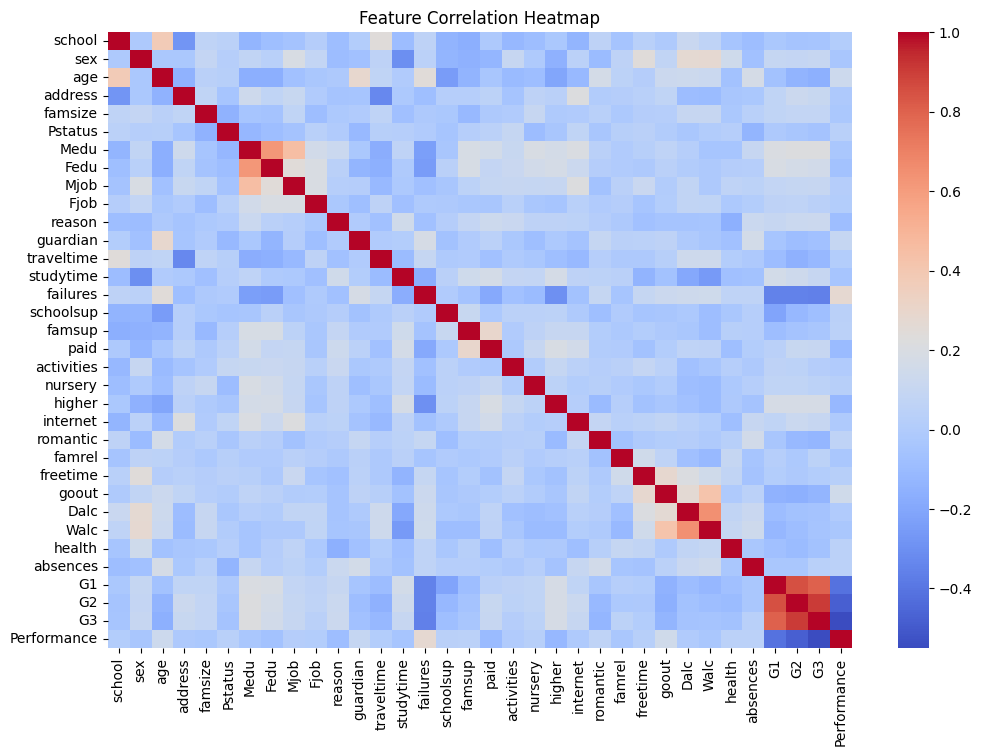

In [47]:
# Dashboard Chart 5
# Display correlation among numerical features

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64']).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [48]:
# Predict performance for a sample student

sample_student = X_test.iloc[[0]]

prediction = model.predict(sample_student)

print("Predicted Performance Category:", prediction)

Predicted Performance Category: [2]


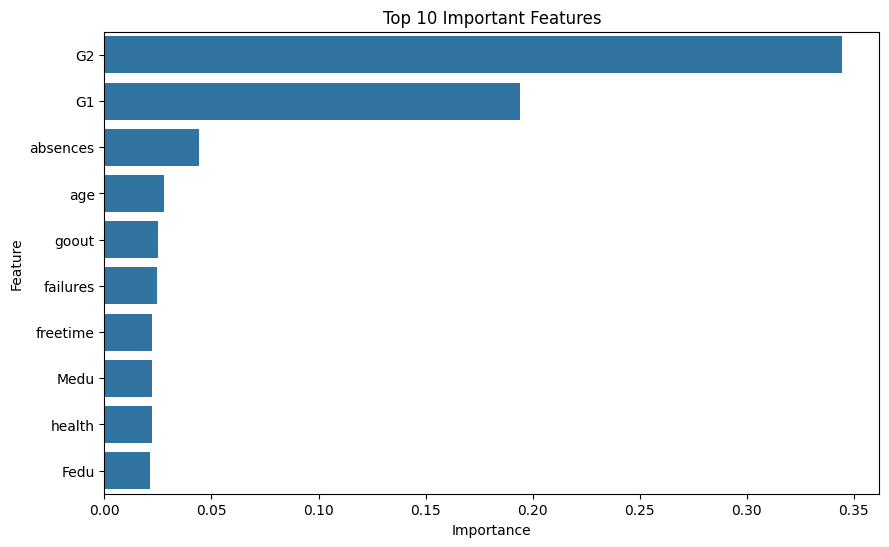

In [49]:
# Identify most important features used by Random Forest

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

# Sort features based on importance

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

# Plot top 10 important features

plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

In [50]:
# Display project conclusion

print("PROJECT COMPLETED SUCCESSFULLY")

print("""

Conclusion:

1. Student Performance Prediction System was developed successfully.

2. Student data was cleaned and preprocessed.

3. Exploratory Data Analysis (EDA) was performed.

4. Random Forest Classifier was used for prediction.

5. Model achieved an accuracy of 86.08%.

6. Feature importance analysis was performed.

7. Recommendation system was developed.

8. Dashboard visualizations were generated.

9. The system can classify students into:
   - Low Performance
   - Average Performance
   - High Performance

10. The project can help educational institutions identify students who need support.

""")

PROJECT COMPLETED SUCCESSFULLY


Conclusion:

1. Student Performance Prediction System was developed successfully.

2. Student data was cleaned and preprocessed.

3. Exploratory Data Analysis (EDA) was performed.

4. Random Forest Classifier was used for prediction.

5. Model achieved an accuracy of 86.08%.

6. Feature importance analysis was performed.

7. Recommendation system was developed.

8. Dashboard visualizations were generated.

9. The system can classify students into:
   - Low Performance
   - Average Performance
   - High Performance

10. The project can help educational institutions identify students who need support.


